# Análisis exploratorio de datos

## 1. Importación de librerías

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from shapely.geometry import Polygon
from io import StringIO


## 2. Obtención y carga de datos

En el request se piden datos desde septiembre de 2016 a septiembre de 2026 en un box que incluya todo el territorio argentino.


In [ ]:
# Importo los datos

url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

params = {
    "format": "csv",
    "starttime": "2016-09-15",
    "endtime": "2026-09-15",
    "minlatitude": -90,
    "maxlatitude": -21.7,
    "minlongitude": -75,
    "maxlongitude": -25,
    "limit": 20000
}

response = requests.get(url, params=params)
response.raise_for_status()



In [119]:
# DataFrame

df = pd.read_csv(StringIO(response.text))

Análisis superficial de los datos para verificar su integridad.

In [6]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])


Filas: 10793
Columnas: 22


In [113]:
pd.set_option('display.max_columns', None)

df.head(3)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-09-14T05:03:12.877Z,-24.1313,-66.9986,189.041,4.4,mb,35.0,77.0,2.572,0.66,us,us7000than,2026-09-14T06:21:54.040Z,"69 km W of San Antonio de los Cobres, Argentina",earthquake,3.33,13.010,0.149,13.0,reviewed,us,us
1,2026-09-13T19:40:25.248Z,-26.1559,-66.5753,10.000,4.7,mb,43.0,54.0,3.508,0.72,us,us7000th7y,2026-09-13T20:22:09.040Z,"60 km W of Cafayate, Argentina",earthquake,6.22,1.890,0.093,35.0,reviewed,us,us
2,2026-09-13T12:36:14.144Z,-33.3311,-72.5473,10.000,3.9,mwr,40.0,77.0,0.815,1.02,us,us7000th65,2026-09-13T13:08:44.040Z,"90 km WNW of Cartagena, Chile",earthquake,4.36,1.839,0.053,34.0,reviewed,us,us


In [118]:
# Guardado de datos originales en .csv

df.to_csv("../data/raw/sismos_usgs.csv", index=False)


Visualización de los datos obtenidos

**Fuente:** https://www.ign.gob.ar/NuestrasActividades/InformacionGeoespacial/CapasSIG


In [9]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326"
)

In [ ]:
# lectura archivo SHP para graficar: Sudamerica(Poligono) y Argentina(Linea) (IGN)

ign_sudam = gpd.read_file("../data/raw/geodata/referencias.shp")
ign_arg   = gpd.read_file("../data/raw/geodata/limites.shp")


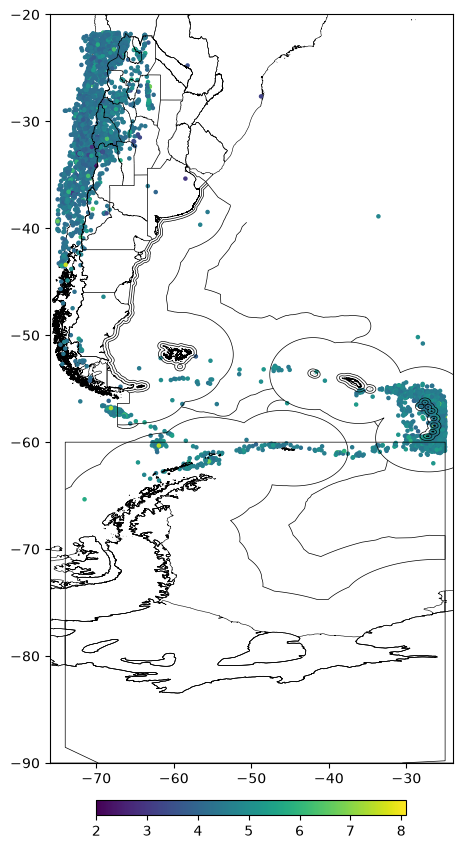

In [11]:

fig, ax = plt.subplots(figsize=(10, 12))

ign_sudam.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4
)

ign_arg.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

gdf.plot(
    ax=ax,
    column="mag",
    cmap="viridis",
    markersize=5,
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.4,
        "pad": 0.04
    }
)

# Zoom sobre Argentina y alrededores
ax.set_xlim(-76, -24)
ax.set_ylim(-90, -20)

plt.show()

## 3. Definición del área de estudio

In [ ]:

# lectura de archivos SHP: provincias y plataforma continental (IGN)

ign_provincias = gpd.read_file("../data/raw/geodata/provinciaPolygon.shp")
ign_plataforma = gpd.read_file("../data/raw/geodata/plataforma_continentalPolygon.shp")


# armado del sector antártico argentino

coordenadas_antartida = [
    (-74.0, -60.0),  # Esquina Noroeste
    (-25.0, -60.0),  # Esquina Noreste
    (-25.0, -90.0),  # Polo Sur (Límite Este)
    (-74.0, -90.0),  # Polo Sur (Límite Oeste)
    (-74.0, -60.0)   # Cierre
]

poligono_antartico = Polygon(coordenadas_antartida)

# Unión de las 3 geometrías en un solo polígono

poligono_nacional = (
    ign_provincias.union_all()
    .union(ign_plataforma.union_all())
    .union(poligono_antartico)
)



In [152]:
# filtrado de puntos ubicados dentro del polígono

gdf_arg = gdf[gdf.geometry.within(poligono_nacional)]

df_arg = pd.DataFrame(gdf_arg.drop(columns='geometry'))


Visualización de los sismos en Argentina entre 2016 y 2026

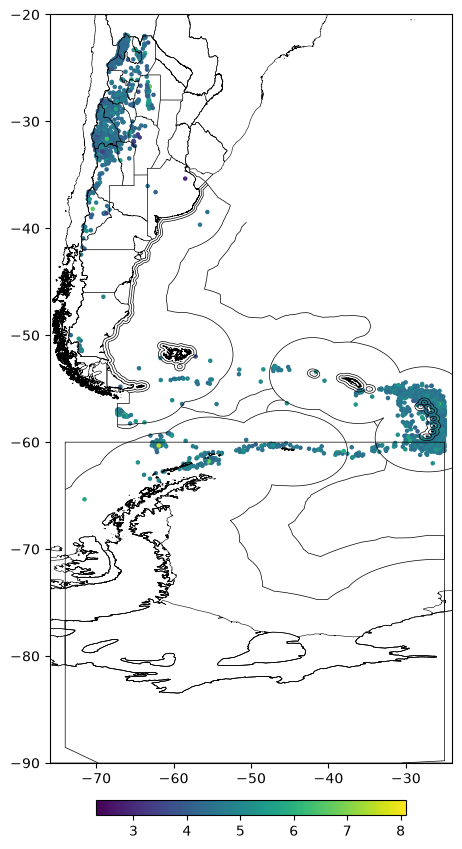

In [ ]:

fig, ax = plt.subplots(figsize=(10, 12))

ign_sudam.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4
)

ign_arg.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

gdf_arg.plot(
    ax=ax,
    column="mag",
    cmap="viridis",
    markersize=5,
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.4,
        "pad": 0.04
    }
)

# Zoom sobre Argentina y alrededores
ax.set_xlim(-76, -24)
ax.set_ylim(-90, -20)

plt.show()

## 4. Exploración inicial del conjunto de datos

### 4.1 Estructura y tipos de datos

In [15]:
print("Filas:", df_arg.shape[0])
print("Columnas:", df_arg.shape[1])


Filas: 6429
Columnas: 22


In [16]:
df_arg.head(3)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-09-14T05:03:12.877Z,-24.1313,-66.9986,189.041,4.4,mb,35.0,77.0,2.572,0.66,...,2026-09-14T06:21:54.040Z,"69 km W of San Antonio de los Cobres, Argentina",earthquake,3.33,13.010,0.149,13.0,reviewed,us,us
1,2026-09-13T19:40:25.248Z,-26.1559,-66.5753,10.000,4.7,mb,43.0,54.0,3.508,0.72,...,2026-09-13T20:22:09.040Z,"60 km W of Cafayate, Argentina",earthquake,6.22,1.890,0.093,35.0,reviewed,us,us
3,2026-09-12T11:05:46.433Z,-56.2951,-26.9013,102.352,4.9,mb,30.0,67.0,5.836,0.79,...,2026-09-23T07:20:17.040Z,South Sandwich Islands region,earthquake,12.33,7.797,0.106,28.0,reviewed,us,us


In [95]:
df_arg.describe().round(3)

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,6429.000,6429.000,6429.000,6429.000,2556.000,6421.000,6421.000,6427.000,6427.000,6429.000,6202.000,6200.000
mean,-45.516,-45.238,90.140,4.589,42.128,86.639,5.387,0.752,9.494,5.429,0.136,28.407
std,15.800,19.740,94.035,0.395,35.253,40.161,4.689,0.234,3.027,3.863,0.069,36.068
min,-65.344,-73.275,1.000,2.300,7.000,12.000,0.041,0.090,1.500,0.600,0.022,1.000
25%,-58.759,-66.936,10.000,4.300,21.000,58.000,1.615,0.590,7.300,1.900,0.089,11.000
50%,-55.850,-30.820,43.330,4.500,30.000,79.000,4.844,0.730,9.420,4.900,0.123,18.000
75%,-24.919,-26.055,167.583,4.800,51.000,107.000,7.461,0.900,11.570,7.800,0.164,33.000
max,-21.880,-25.002,626.010,8.100,466.000,292.000,32.456,2.480,28.300,32.700,0.539,663.000


In [17]:
df_arg.info()

<class 'pandas.DataFrame'>
Index: 6429 entries, 0 to 10792
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             6429 non-null   str    
 1   latitude         6429 non-null   float64
 2   longitude        6429 non-null   float64
 3   depth            6429 non-null   float64
 4   mag              6429 non-null   float64
 5   magType          6429 non-null   str    
 6   nst              2556 non-null   float64
 7   gap              6421 non-null   float64
 8   dmin             6421 non-null   float64
 9   rms              6427 non-null   float64
 10  net              6429 non-null   str    
 11  id               6429 non-null   str    
 12  updated          6429 non-null   str    
 13  place            6429 non-null   str    
 14  type             6429 non-null   str    
 15  horizontalError  6427 non-null   float64
 16  depthError       6429 non-null   float64
 17  magError         6202 non-nul

### 4.2 Valores faltantes

In [18]:
nulos = df_arg.isna().sum()
nulos[nulos>0]

nst                3873
gap                   8
dmin                  8
rms                   2
horizontalError       2
magError            227
magNst              229
dtype: int64

In [19]:
# Análisis porcentual de nulos

((nulos[nulos>0]/df_arg.shape[0])*100).round(3)

nst                60.243
gap                 0.124
dmin                0.124
rms                 0.031
horizontalError     0.031
magError            3.531
magNst              3.562
dtype: float64

Nst presenta aproximadamente un 60 % de valores faltantes, por lo que se propone excluirla del análisis posterior. Para las restantes variables, los faltantes representan una proporción reducida y se propone imputarlos mediante la mediana durante la etapa de transformación.

### 4.3 Registros duplicados


In [20]:
id = df_arg["id"].value_counts()
id[id>1]

Series([], Name: count, dtype: int64)

In [21]:
df_arg.duplicated().value_counts()

False    6429
Name: count, dtype: int64

No existen filas ni identificadores duplicados.

### 4.4 Variables categóricas


#### 4.4.1 Última actualización del evento

In [23]:
df_arg["updated"].value_counts()

updated
2024-08-16T21:59:24.040Z    18
2026-01-01T23:11:08.040Z    11
2025-07-12T16:30:42.040Z    11
2021-10-29T14:47:05.040Z    11
2021-10-29T14:46:49.040Z    11
                            ..
2016-12-12T23:01:28.040Z     1
2025-12-22T17:17:54.106Z     1
2016-12-12T23:01:27.040Z     1
2016-12-12T23:01:26.040Z     1
2025-12-22T17:17:51.214Z     1
Name: count, Length: 4762, dtype: int64

#### 4.4.2 Fecha y hora exacta del evento

In [24]:
df_arg["time"].value_counts()

time
2026-09-14T05:03:12.877Z    1
2026-09-13T19:40:25.248Z    1
2026-09-12T11:05:46.433Z    1
2026-09-09T10:06:57.170Z    1
2026-09-08T06:50:46.470Z    1
                           ..
2016-09-17T01:02:21.620Z    1
2016-09-16T12:04:39.700Z    1
2016-09-15T04:50:34.110Z    1
2016-09-15T02:37:59.150Z    1
2016-09-15T01:06:30.870Z    1
Name: count, Length: 6429, dtype: int64

Las columnas “updated” y “time” se transformarán a tipo DateTime en la etapa de transformación.

#### 4.4.3 Tipo de medición de magnitud

In [22]:

df_arg["magType"].value_counts()

magType
mb       5648
mww       458
mwr       267
ml         45
md          6
mw          2
mb_lg       2
mwb         1
Name: count, dtype: int64

No presenta categorías o valores que requieran un tratamiento particular.

#### 4.4.4 Estado de revisión

In [25]:
df_arg["status"].value_counts()

status
reviewed    6429
Name: count, dtype: int64

#### 4.4.5 Tipo de evento

In [26]:
df_arg["type"].value_counts()

type
earthquake    6429
Name: count, dtype: int64

#### 4.4.6 Red sísmica de preferencia para el evento

In [27]:
df_arg["net"].value_counts()

net
us        6427
iscgem       2
Name: count, dtype: int64

#### 4.4.7 Red sísmica que localizó el evento

In [28]:
df_arg["locationSource"].value_counts()

locationSource
us        6421
sja          4
iscgem       2
guc          2
Name: count, dtype: int64

#### 4.4.8 Red sísmica que calculó la magnitud

In [29]:
df_arg["magSource"].value_counts()

magSource
us        6205
guc        216
sja          6
iscgem       2
Name: count, dtype: int64

Las variables categóricas con una categoría ampliamente predominante presentan poca variabilidad dentro del conjunto de datos y tienen una utilidad limitada para los análisis planteados. Por este motivo, se propone no considerarlas en el análisis posterior.

## 5. Análisis de magnitud y error de magnitud


### 5.1 Distribución de la magnitud


In [31]:
df_arg['mag'].value_counts().sort_index()

mag
2.30      1
3.00      2
3.30      5
3.40      6
3.50      1
3.60      1
3.70      4
3.80     13
3.90     25
4.00    177
4.10    262
4.20    523
4.30    729
4.40    816
4.50    912
4.60    770
4.70    503
4.80    270
4.90    394
5.00    309
5.06      1
5.10    212
5.18      1
5.20    138
5.30     90
5.40     58
5.50     46
5.60     47
5.70     35
5.80     10
5.90     11
6.00     13
6.10     10
6.20      6
6.30      4
6.40     10
6.50      3
6.60      3
6.70      1
6.80      2
6.90      1
7.50      2
7.60      1
8.10      1
Name: count, dtype: int64

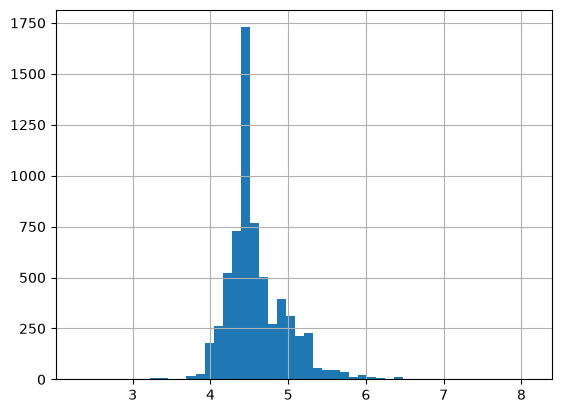

In [32]:
df_arg['mag'].hist(bins= 50)
plt.show()

Análisis de variables atípicas

In [ ]:
index1 = df_arg[df_arg['mag']==5.06].index
index2 = df_arg[df_arg['mag']==5.18].index

In [112]:
df_arg[df_arg["mag"].isin([5.06, 5.18])]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
4846,2021-12-04T04:32:02.340Z,-59.762,-29.666,10.0,5.06,mw,NaN,NaN,NaN,NaN,iscgem,iscgem621613005,2025-12-22T22:21:35.177Z,South Sandwich Islands region,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem
6304,2021-03-14T14:09:13.950Z,-59.303,-31.041,10.0,5.18,mw,NaN,NaN,NaN,NaN,iscgem,iscgem620210242,2025-12-22T18:55:19.233Z,Scotia Sea,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem


Se identificaron dos registros con valores de magnitud que resultan atípicos respecto del resto del conjunto de datos. Ambos presentan valores faltantes simultáneamente en nst, gap, dmin, rms, horizontalError y magNst, siendo estas variables de calidad. Al no poder evaluar la confiabilidad de las mediciones se recomienda excluir ambos registros del análisis posterior.

### 5.2 Error de magnitud


In [69]:
bins = [0, 1, 2, 3, 4, 4.5, 5, 6, 7, 8, 9, 10]

mag_groups = pd.cut(
    bins=bins,
    df_arg['mag'],
    include_lowest=True
)


mag_error_summary = (
    df_arg
    .groupby(mag_groups, observed=True)['magError']
    .agg(
        count='count',
        median='median',
        q3=lambda x: x.quantile(0.75),
        max='max'
    )
)


mag_error_summary

,count,median,q3,max
mag,,,,
"(2.0, 3.0]",3,0.058,0.1765,0.295
"(3.0, 4.0]",215,0.232,0.2970,0.520
"(4.0, 4.5]",3092,0.154,0.1970,0.539
"(4.5, 5.0]",2190,0.102,0.1230,0.385
"(5.0, 6.0]",659,0.069,0.0830,0.152
"(6.0, 7.0]",39,0.048,0.0590,0.105
"(7.0, 8.0]",3,0.041,0.0520,0.063
"(8.0, 9.0]",1,0.065,0.0650,0.065


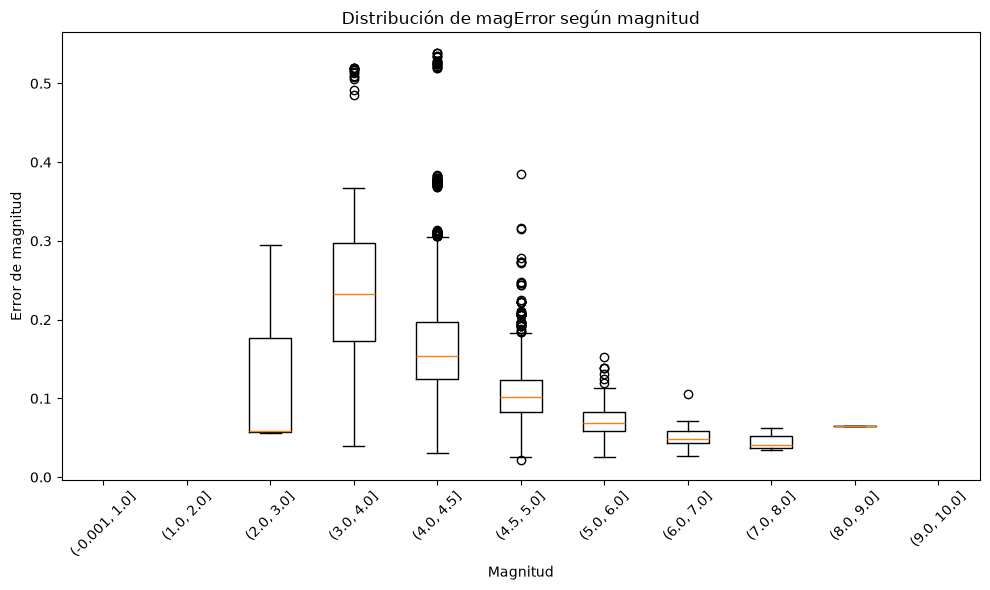

In [70]:
data_boxplot = [
    df_arg.loc[mag_groups == grupo, 'magError'].dropna()
    for grupo in mag_groups.cat.categories
]

labels = [
    str(grupo)
    for grupo in mag_groups.cat.categories
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data_boxplot,
    tick_labels=labels
)

plt.xlabel('Magnitud')
plt.ylabel('Error de magnitud')
plt.title('Distribución de magError según magnitud')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:

df_arg[(df_arg["magError"]>=0.4) & (df_arg["mag"]>4) & (df_arg["mag"]<=4.5)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
712,2025-11-24T14:18:18.405Z,-30.9301,-69.0523,115.172,4.1,mb,23.0,127.0,0.695,0.57,us,us6000rq39,2026-02-20T16:07:36.040Z,"56 km NE of Calingasta, Argentina",earthquake,4.97,6.054,0.520,1.0,reviewed,us,us
1565,2025-02-18T19:49:19.657Z,-24.2802,-67.1293,196.298,4.2,mb,27.0,136.0,1.636,0.55,us,us7000pekv,2025-05-02T16:26:22.040Z,"82 km W of San Antonio de los Cobres, Argentina",earthquake,7.97,11.314,0.529,1.0,reviewed,us,us
3844,2022-09-25T17:02:28.568Z,-23.3799,-66.8356,222.538,4.4,mb,18.0,101.0,1.307,0.22,us,us7000iays,2022-12-03T22:03:23.040Z,"106 km NNW of San Antonio de los Cobres, Argen...",earthquake,6.78,14.065,0.538,3.0,reviewed,us,us
4175,2022-06-01T19:42:37.746Z,-28.1369,-67.0873,161.740,4.4,mb,28.0,136.0,2.838,0.55,us,us7000he6b,2022-08-06T22:13:14.040Z,"47 km S of Londres, Argentina",earthquake,10.70,5.200,0.535,1.0,reviewed,us,us
6504,2021-01-08T12:54:17.688Z,-26.5272,-65.7243,10.000,4.1,mb,NaN,108.0,4.215,0.87,us,us6000d6qr,2021-03-20T21:22:50.040Z,"36 km N of Tafí del Valle, Argentina",earthquake,8.80,1.900,0.521,1.0,reviewed,us,us
6862,2020-10-01T16:50:02.581Z,-24.1584,-66.8462,184.880,4.1,mb,NaN,112.0,1.713,1.26,us,us6000c416,2020-12-12T22:28:30.040Z,"53 km W of San Antonio de los Cobres, Argentina",earthquake,8.10,6.800,0.520,2.0,reviewed,us,us
7049,2020-08-14T12:31:47.447Z,-22.6196,-66.3129,259.250,4.1,mb,NaN,134.0,1.753,0.48,us,us6000bhna,2020-10-24T20:09:06.040Z,"64 km W of Abra Pampa, Argentina",earthquake,13.10,9.600,0.521,1.0,reviewed,us,us
7365,2020-04-14T16:49:18.091Z,-23.1204,-66.8896,241.190,4.1,mb,NaN,175.0,1.199,0.47,us,us70008w46,2020-06-30T14:03:10.040Z,"124 km W of El Aguilar, Argentina",earthquake,15.30,9.200,0.522,1.0,reviewed,us,us
7433,2020-03-24T21:13:03.645Z,-23.3583,-67.0925,213.920,4.2,mb,NaN,78.0,1.078,0.74,us,us70008fcu,2020-06-06T20:54:16.040Z,"123 km NW of San Antonio de los Cobres, Argentina",earthquake,5.60,13.700,0.526,1.0,reviewed,us,us
9409,2017-11-19T14:27:10.300Z,-24.0257,-67.3054,198.830,4.4,mb,NaN,128.0,1.336,0.45,us,us2000brfz,2018-02-14T02:01:03.040Z,"102 km WNW of San Antonio de los Cobres, Argen...",earthquake,8.50,19.600,0.535,1.0,reviewed,us,us


In [79]:
pd.set_option('display.max_columns', None)

df_arg[(df_arg["magError"]>=0.37) & (df_arg["mag"]>4.5) & (df_arg["mag"]<=5)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
7456,2020-03-10T13:07:32.821Z,-28.5433,-68.803,130.4,4.6,mb,NaN,79.0,1.324,0.55,us,us60008d4l,2020-05-23T22:03:16.040Z,"63 km WNW of Vinchina, Argentina",earthquake,8.5,8.4,0.385,2.0,reviewed,us,us


No se identifican criterios suficientes para descartar los datos.

## 6. Análisis de profundidad y error de profundidad

### 6.1 Distribución de la profundidad


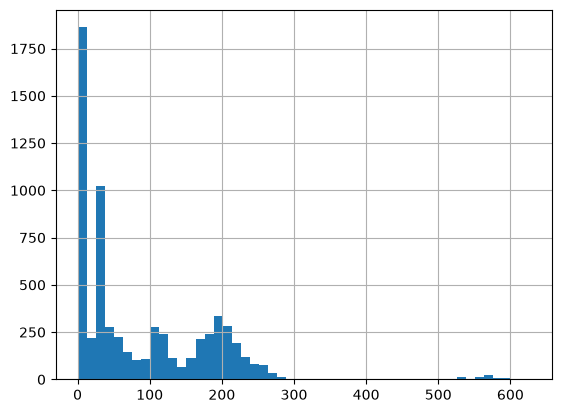

In [39]:
df_arg['depth'].hist(bins= 50)
plt.show()

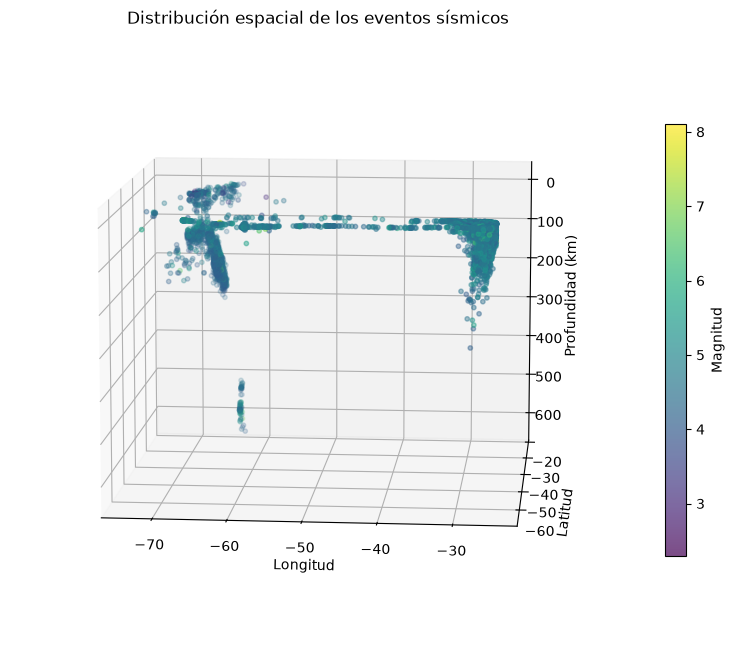

In [ ]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_arg['longitude'],
    df_arg['latitude'],
    df_arg['depth'],
    c=df_arg['mag'],
    cmap='viridis',
    s=10,
    alpha=0.7
)

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_zlabel('Profundidad (km)')

ax.invert_zaxis()

ax.view_init(elev=10, azim=-85)

ax.set_title('Distribución espacial de los eventos sísmicos')

fig.colorbar(
    scatter,
    ax=ax,
    label='Magnitud',
    shrink=0.7
)

plt.show()

Los eventos con profundidades superiores a 500 km se conservarán en el conjunto de datos, ya que su profundidad no constituye por sí misma un criterio suficiente para considerarlos registros anómalos.

### 6.2 Error de profundidad


In [46]:
bins = [0, 10, 20, 40, 65, 100, 200, 300, 400, 500, 600, 650]

depth_groups = pd.cut(
    df_arg['depth'],
    bins=bins,
    include_lowest=True
)


depth_error_summary = (
    df_arg
    .groupby(depth_groups, observed=True)['depthError']
    .agg(
        count='count',
        median='median',
        q3=lambda x: x.quantile(0.75),
        max='max'
    )
)


depth_error_summary

,count,median,q3,max
depth,,,,
"(-0.001, 10.0]",1805,1.900,1.90000,25.000
"(10.0, 20.0]",163,4.400,5.20000,8.005
"(20.0, 40.0]",1178,2.000,5.10000,21.700
"(40.0, 65.0]",480,6.900,8.50000,16.002
"(65.0, 100.0]",321,6.796,8.10000,19.210
"(100.0, 200.0]",1580,7.200,9.11525,25.700
"(200.0, 300.0]",829,9.500,12.32900,32.700
"(300.0, 400.0]",1,10.300,10.30000,10.300
"(500.0, 600.0]",68,6.841,8.24450,18.600


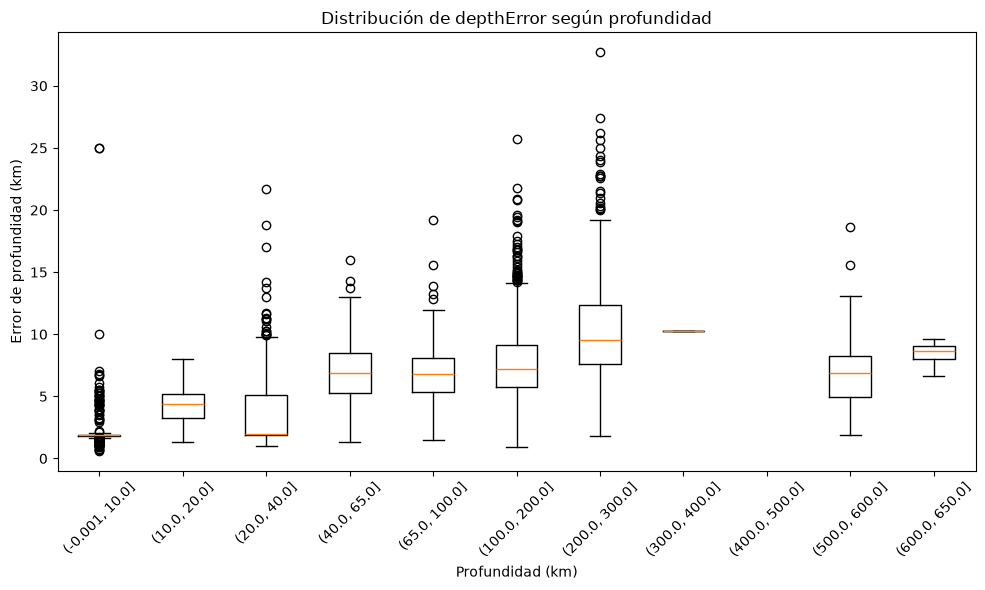

In [49]:
data_boxplot = [
    df_arg.loc[depth_groups == grupo, 'depthError'].dropna()
    for grupo in depth_groups.cat.categories
]

labels = [
    str(grupo)
    for grupo in depth_groups.cat.categories
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data_boxplot,
    tick_labels=labels
)

plt.xlabel('Profundidad (km)')
plt.ylabel('Error de profundidad (km)')
plt.title('Distribución de depthError según profundidad')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observación de valores extremos

In [ ]:

df_arg[(df_arg["depthError"]==25) & (df_arg["depth"]<11)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
4846,2021-12-04T04:32:02.340Z,-59.762,-29.666,10.0,5.06,mw,NaN,NaN,NaN,NaN,iscgem,iscgem621613005,2025-12-22T22:21:35.177Z,South Sandwich Islands region,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem
6304,2021-03-14T14:09:13.950Z,-59.303,-31.041,10.0,5.18,mw,NaN,NaN,NaN,NaN,iscgem,iscgem620210242,2025-12-22T18:55:19.233Z,Scotia Sea,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem


In [ ]:

df_arg[(df_arg["depthError"]>=15) & (df_arg["depth"]>20) & (df_arg["depth"]<41)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
5258,2021-09-05T18:38:59.897Z,-59.7193,-26.4103,36.14,4.4,mb,NaN,201.0,7.737,1.22,us,us7000fate,2021-11-17T17:23:34.040Z,South Sandwich Islands region,earthquake,20.2,18.8,0.139,15.0,reviewed,us,us
7999,2019-07-15T09:06:19.255Z,-25.4759,-64.4012,37.00,4.3,mb,NaN,45.0,4.266,1.16,us,us70004kgk,2019-09-28T20:01:25.040Z,"27 km ESE of El Galpón, Argentina",earthquake,7.7,17.0,0.308,4.0,reviewed,us,us
9867,2017-05-25T12:10:58.310Z,-30.1939,-67.2047,36.77,4.5,mb,NaN,66.0,1.853,1.29,us,us10008v9q,2017-08-10T01:34:01.040Z,"54 km NNE of San Agustín de Valle Fértil, Arge...",earthquake,6.7,21.7,0.312,3.0,reviewed,us,us


In [ ]:

df_arg[(df_arg["depthError"]==25.700) & (df_arg["depth"]>100) & (df_arg["depth"]<201)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
7953,2019-08-11T15:02:40.811Z,-28.2586,-67.569,167.69,4.1,ml,NaN,187.0,1.982,0.13,us,us600053qt,2019-10-29T20:33:59.040Z,"21 km S of Tinogasta, Argentina",earthquake,11.8,25.7,0.064,32.0,reviewed,us,us


In [ ]:
df_arg[(df_arg["depthError"]==32.700) & (df_arg["depth"]<301)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
9891,2017-05-16T18:05:30.780Z,-23.9779,-66.9937,243.36,4.1,ml,NaN,222.0,2.225,0.97,us,us10008ssu,2017-08-05T03:32:09.040Z,"73 km WNW of San Antonio de los Cobres, Argentina",earthquake,10.3,32.7,NaN,NaN,reviewed,us,guc


No se identifican criterios suficientes para descartar los datos.

### 6.3 Análisis de registros con múltiples valores faltantes


Se analiza por la reiterada presencia de datos con varias columnas NaN.


In [ ]:

df_nan = df_arg.isna().sum(axis=1)

df_arg.loc[
    df_nan > 2, ["depth","depthError","mag","magError", "magNst","gap","dmin","rms","nst","horizontalError" ]
].assign(
    nan_count=df_nan
).sort_values(
    by='nan_count',
    ascending=False
)

,depth,depthError,mag,magError,magNst,gap,dmin,rms,nst,horizontalError,nan_count
4846,10.00,25.0,5.06,0.100,NaN,NaN,NaN,NaN,NaN,NaN,6
6304,10.00,25.0,5.18,0.100,NaN,NaN,NaN,NaN,NaN,NaN,6
10520,223.00,6.0,5.00,NaN,NaN,NaN,NaN,1.88,NaN,7.1,5
10626,33.00,10.1,3.30,NaN,NaN,NaN,NaN,0.59,NaN,11.2,5
4621,118.79,3.8,4.70,NaN,NaN,42.0,0.884,0.91,NaN,5.6,3
...,...,...,...,...,...,...,...,...,...,...,...
10566,250.41,12.7,4.00,NaN,NaN,233.0,1.510,0.71,NaN,8.1,3
10610,208.74,7.6,4.60,NaN,NaN,41.0,1.764,0.75,NaN,8.0,3
10613,148.98,6.7,4.70,NaN,NaN,28.0,2.437,0.79,NaN,7.7,3
10679,10.00,4.6,5.00,0.133,18.0,NaN,NaN,0.83,NaN,7.4,3


In [ ]:
# cuales son los id de los registros con 5 o más valores NaN

nan_count = df_arg.isna().sum(axis=1)

registros_incompletos = df_arg[nan_count >= 5]

registros_incompletos["id"].tolist()

['iscgem621613005', 'iscgem620210242', 'us10007f0t', 'us100073ln']

Los registros que presentan 5 o 6 variables NaN quedan practicamente sin variables de métrica de calidad, por lo que propongo descartarlos (notar que las primeras dos ya se había propuesto descartarlas). El resto tienen 3 métricas faltantes, como no todas tienen el mismo peso, veo que patrones existen:

In [61]:
df_arg.loc[
    df_nan == 3,
    ['nst', 'gap', 'dmin', 'rms', 'horizontalError', 'depthError', 'magError', 'magNst']
].isna().astype(int).value_counts()


nst  gap  dmin  rms  horizontalError  depthError  magError  magNst
1    0    0     0    0                0           1         1         146
     1    1     0    0                0           0         0           4
Name: count, dtype: int64

En un principio, según estos resultados, podrían mantenerse todas filas con 3 variables NaN.

## 7. Análisis de variables de calidad


### 7.1 Error horizontal


In [91]:
df_arg["horizontalError"].describe()

count    6427.000000
mean        9.494383
std         3.027203
min         1.500000
25%         7.300000
50%         9.420000
75%        11.570000
max        28.300000
Name: horizontalError, dtype: float64

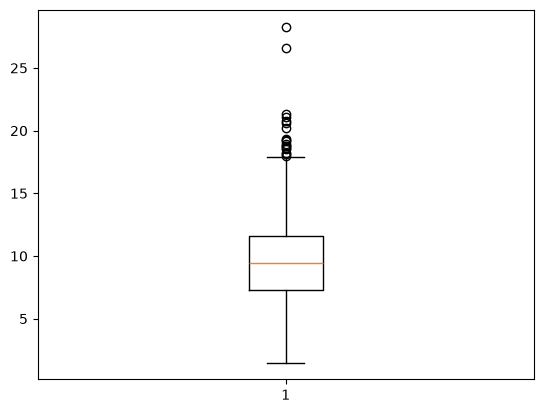

In [90]:
plt.boxplot(df_arg["horizontalError"].dropna())
plt.show()

In [ ]:

df_arg[(df_arg["horizontalError"]>=25)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
740,2025-11-13T02:44:20.935Z,-58.9814,-25.7406,87.293,4.4,mb,14.0,234.0,7.565,1.11,us,us7000rf2m,2026-02-10T15:55:17.040Z,South Sandwich Islands region,earthquake,26.59,19.21,0.143,14.0,reviewed,us,us
8443,2019-01-04T19:45:03.470Z,-60.6901,-26.5353,10.000,4.7,mb,NaN,164.0,14.442,1.03,us,us2000j7be,2019-03-08T17:50:21.040Z,South Sandwich Islands region,earthquake,28.30,1.90,0.152,14.0,reviewed,us,us


### 7.2 Gap


In [103]:
df_arg["gap"].describe()

count    6421.000000
mean       86.639153
std        40.160676
min        12.000000
25%        58.000000
50%        79.000000
75%       107.000000
max       292.000000
Name: gap, dtype: float64

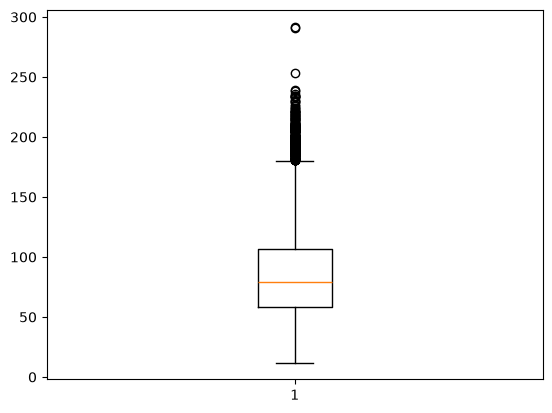

In [106]:
plt.boxplot(df_arg["gap"].dropna())
plt.show()

In [114]:
df_arg[(df_arg["gap"]>=290)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
338,2026-05-06T01:19:20.881Z,-31.8481,-65.1886,10.0,3.3,ml,14.0,292.0,2.983,0.66,us,us6000svif,2026-07-15T15:25:55.040Z,"10 km N of Villa Dolores, Argentina",earthquake,6.03,2.027,0.081,20.0,reviewed,us,us
7242,2020-05-30T13:17:23.330Z,-60.8367,-26.3896,10.0,4.6,mb,NaN,291.0,8.513,0.54,us,us6000a6gy,2020-08-15T20:19:53.040Z,South Sandwich Islands region,earthquake,9.80,2.000,0.132,17.0,reviewed,us,us


### 7.3 Distancia mínima


In [104]:
df_arg["dmin"].describe()

count    6421.000000
mean        5.386914
std         4.689080
min         0.041000
25%         1.615000
50%         4.844000
75%         7.461000
max        32.456000
Name: dmin, dtype: float64

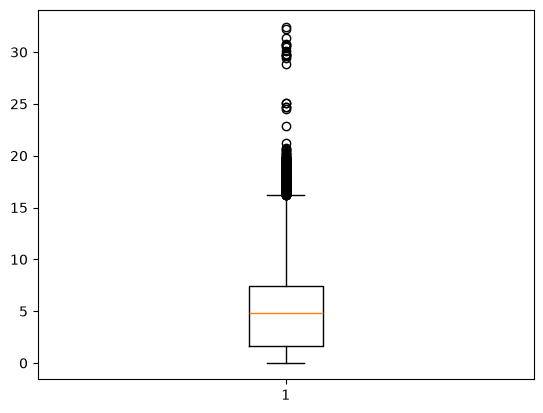

In [107]:
plt.boxplot(df_arg["dmin"].dropna())
plt.show()

### 7.4 RMS


In [105]:
df_arg["rms"].describe()

count    6427.000000
mean        0.751923
std         0.234376
min         0.090000
25%         0.590000
50%         0.730000
75%         0.900000
max         2.480000
Name: rms, dtype: float64

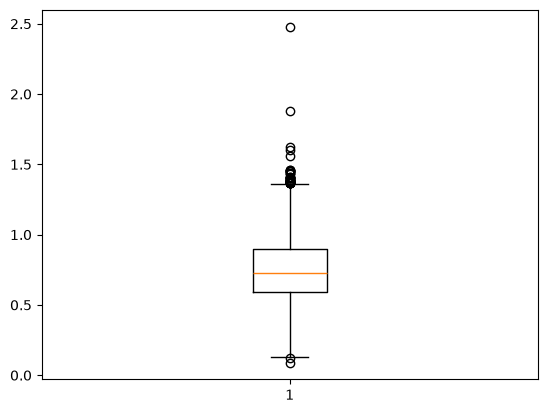

In [108]:
plt.boxplot(df_arg["rms"].dropna())
plt.show()

In [116]:
df_arg[(df_arg["rms"]>=2)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
8428,2019-01-09T17:55:27.940Z,-38.5913,-68.6584,1.0,3.4,mb_lg,NaN,221.0,2.403,2.48,us,us2000j8kv,2022-08-08T13:49:38.005Z,"28 km SSE of Añelo, Argentina",earthquake,8.9,10.0,0.085,36.0,reviewed,us,us


### 7.5 Nst de magnitud

In [93]:
df_arg["magNst"].describe()

count    6200.000000
mean       28.406613
std        36.068154
min         1.000000
25%        11.000000
50%        18.000000
75%        33.000000
max       663.000000
Name: magNst, dtype: float64

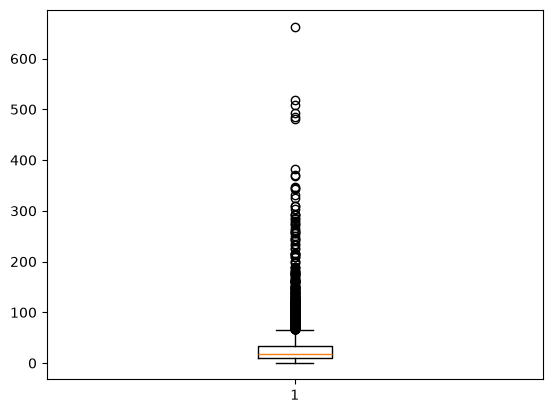

In [109]:
plt.boxplot(df_arg["magNst"].dropna())
plt.show()

In [117]:
df_arg[(df_arg["magNst"]>=600)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
1090,2025-07-13T05:56:58.916Z,-24.1879,-66.7496,182.238,5.0,mb,75.0,48.0,1.798,1.11,us,us7000qcd6,2025-11-28T21:03:51.047Z,"43 km W of San Antonio de los Cobres, Argentina",earthquake,8.94,6.031,0.022,663.0,reviewed,us,us


Las variables de calidad, aunque presentan valores elevados, al observarlos en detalle no se encuentran otras particularidades que hagan dudar de las observaciones, por lo que no se recomienda descartar datos.

## 8. Análisis espacial



<p align="center">
  <img src="../imagenes/placas_tectonicas_sudamerica.png" width="500">
</p>

<p align="center">
  <em>Contexto tectónico de América del Sur y regiones circundantes.</em><br>
  <em>Fuente: Modificado de Bird, 2003.</em>
</p>

Por lo que se puede observar al comparar las imágenes de los apartados 3 y 6.1 con la imagen anterior, se pueden distinguir tres zonas sísmicas principales. La primera corresponde a la subducción de las placas de Nazca y Antártica por debajo de las placas Sudamericana y de Scotia. La segunda se caracteriza por el movimiento transformante asociado a la placa de Scotia y por la presencia predominante de sismos de poca profundidad. Por último, se identifica una tercera zona correspondiente a la subducción de la placa Sudamericana por debajo de la placa de Sandwich. En las zonas de subducción se observa además un rango de profundidades mayor.


## 9. Análisis temporal


### 9.1 Evolución anual



In [ ]:
horario = pd.to_datetime(df_arg['time']).dt.time
año = pd.to_datetime(df_arg['time']).dt.year
mes = pd.to_datetime(df_arg['time']).dt.month

time
2016     175
2017     502
2018     458
2019     433
2020     641
2021    1384
2022     771
2023     580
2024     538
2025     606
2026     341
Name: count, dtype: int64


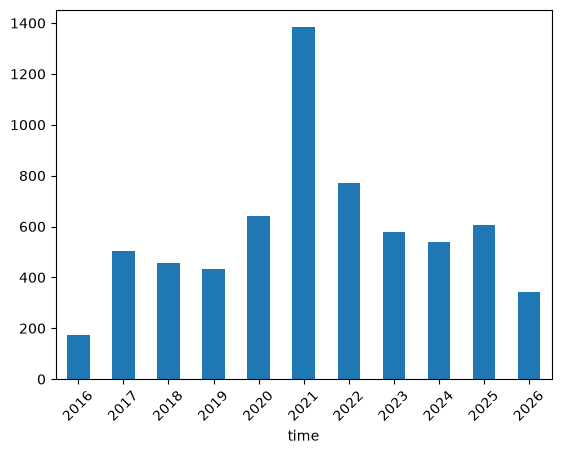

In [153]:

print(año.value_counts().sort_index())

año.value_counts().sort_index().plot(kind="bar")

plt.xticks(rotation=45)
plt.show()

Se observa una distribución anual bastante homogénea salvo para el año 2021 que se estudiará por separado.

### 9.2 Distribución mensual


time
1     509
2     381
3     430
4     464
5     555
6     435
7     451
8     983
9     615
10    587
11    494
12    525
Name: count, dtype: int64


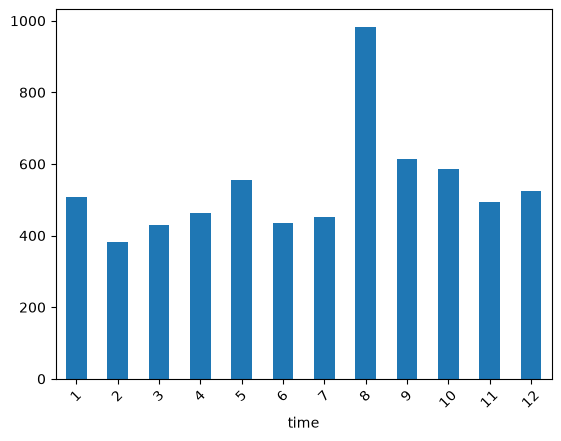

In [134]:
print(mes.value_counts().sort_index())

mes.value_counts().sort_index().plot(kind="bar")

plt.xticks(rotation=45)
plt.show()

Se observa una distribución mensual bastante homogenea salvo para el mes de agosto.
Se verá si el pico del año 2021 está relacionado con el pico de agosto.

In [138]:
pd.crosstab(año, mes)

time,1,2,3,4,5,6,7,8,9,10,11,12
time,,,,,,,,,,,,
2016,0,0,0,0,0,0,0,0,41,48,52,34
2017,46,36,38,40,75,35,50,30,47,36,31,38
2018,17,19,34,48,40,33,41,30,51,52,58,35
2019,32,40,29,33,35,35,38,38,36,48,35,34
2020,41,40,41,61,47,47,44,40,66,95,58,61
2021,103,40,40,49,44,46,36,600,156,86,82,102
2022,84,57,80,89,70,55,54,54,58,55,55,60
2023,51,47,44,33,48,40,53,57,45,67,38,57
2024,59,33,33,44,67,49,44,41,54,31,33,50


Efectivamente hay un pico considerable para agosto de 2021, veremos cuál es la distribución espacial del fenómeno.

In [148]:

df_8_2021 = df_arg[(año == 2021) & (mes == 8)]

dia = pd.to_datetime(df_8_2021['time']).dt.day

gdf_8_2021 = gpd.GeoDataFrame(
    df_8_2021,
    geometry=gpd.points_from_xy(df_8_2021["longitude"], df_8_2021["latitude"]), crs="EPSG:4326"
)

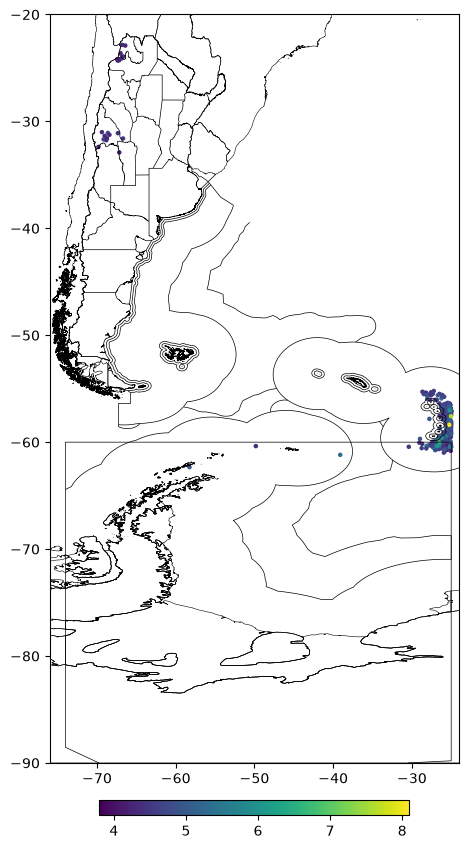

In [144]:

fig, ax = plt.subplots(figsize=(10, 12))

ign_sudam.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4
)

ign_arg.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

gdf_8_2021.plot(
    ax=ax,
    column="mag",
    cmap="viridis",
    markersize=5,
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.4,
        "pad": 0.04
    }
)

# Zoom sobre Argentina y alrededores
ax.set_xlim(-76, -24)
ax.set_ylim(-90, -20)

plt.show()

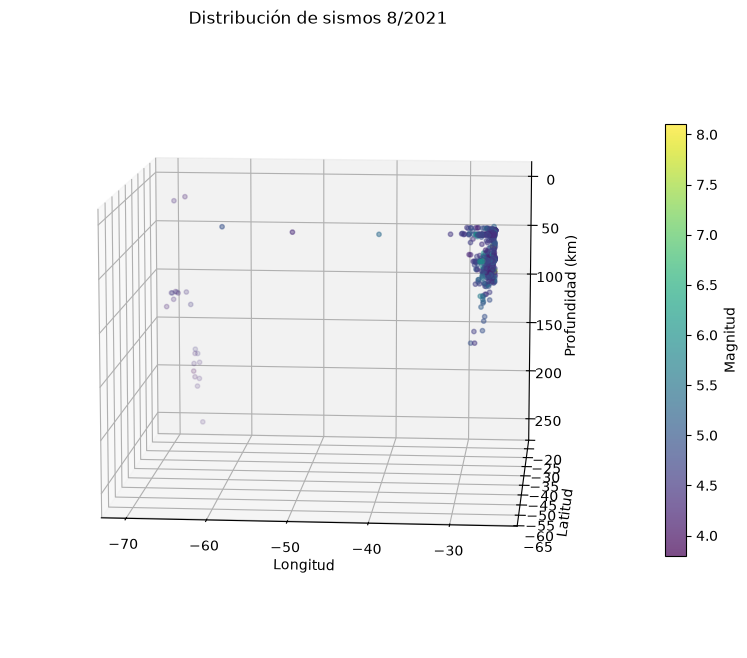

In [141]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_8_2021['longitude'],
    df_8_2021['latitude'],
    df_8_2021['depth'],
    c=df_8_2021['mag'],
    cmap='viridis',
    s=10,
    alpha=0.7
)

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_zlabel('Profundidad (km)')

ax.invert_zaxis()

ax.view_init(elev=10, azim=-85)

ax.set_title('Distribución de sismos 8/2021')

fig.colorbar(
    scatter,
    ax=ax,
    label='Magnitud',
    shrink=0.7
)

plt.show()

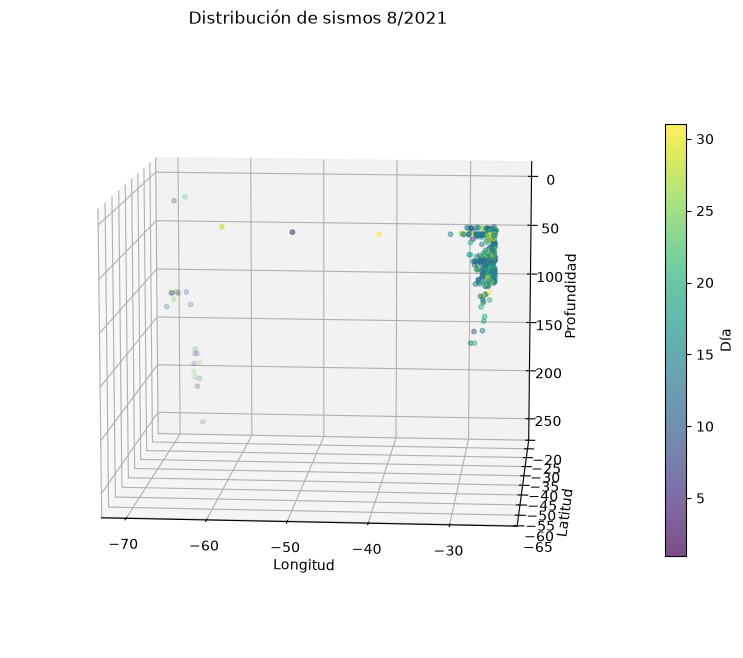

In [151]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_8_2021['longitude'],
    df_8_2021['latitude'],
    df_8_2021['depth'],
    c=dia,
    cmap='viridis',
    s=10,
    alpha=0.7
)

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_zlabel('Profundidad')

ax.invert_zaxis()

ax.view_init(elev=10, azim=-85)

ax.set_title('Distribución de sismos 8/2021')

fig.colorbar(
    scatter,
    ax=ax,
    label='Día',
    shrink=0.7
)

plt.show()

A partir de las imágenes se observan cientos de sismos en la zona de las Islas Sandwich durante el período de estudio, destacándose un evento de magnitud aproximada 8. Al investigar este episodio, se identificó que corresponde a un sismo principal seguido por réplicas registradas durante las semanas posteriores en el mismo sector.


## 10. Requerimientos para la transformación


En resumen se deberían hacer los siguientes cambios en la etapa de transformación:

* Descartar las columnas: "nst", "net", "type", "status", "locationSource", "magSource".
* Descartar las filas de id [iscgem621613005], [iscgem620210242], [us10007f0t], [us100073ln].
* Transformar las columnas "time" y "updated" a tipo DateTime.
* Rellenar los valores Na de las variables "gap", "dmin", "rms", "horizontalError", "magError", "magNst" con las medianas correspondientes.
* Crear columnas nuevas a partir de la variable "time". 

## 11. Conclusiones de la EDA

Más información sobre las variables:

https://earthquake.usgs.gov/data/comcat/data-eventterms.php#nst

https://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php